In [1]:
# ohe: respone_bytes | normalise
# todo: search clusterisation algorithms
# todo: 
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import HashingVectorizer
import ipaddress
import joblib


#### Tasklist
  - [x] rewrite neural network code
  - [x] drop insufficient columns.
  - [x] add OneHotEncoder for http methods, http statuses
  - [x] normalize response body size via log2 func
  - [x] encode user_agent name with label encoder
  - [x] vectorize files
  - [x] vectorize paths
  - [x] drop or process referrer header
    - [ ] drop
    - [x] process
  - [x] drop or process source ip
    - [ ] drop
    - [x] process
  

In [51]:
import ipaddress
import json
import logging
from functools import lru_cache

import joblib
import pandas as pd
import numpy as np
from scipy import sparse
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder


@lru_cache(maxsize=100000)
def _ip_to_int(value: str) -> int:
    try:
        return int(ipaddress.ip_address(value))
    except Exception:
        return 0


class LogVertorizer:
    def __init__(self, ohe_encoding_features: list[str] = None, le_encoding_features: list[str] = None,
                 insufficent_columns: list[str] = None, ohe_filepath: str = None, le_filepath: str = None):
        self.dir_vec = HashingVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            n_features=2 ** 14,
            alternate_sign=False
        )

        self.file_vec = HashingVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            n_features=2 ** 12,
            alternate_sign=False
        )

        self.ref_vec = HashingVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            n_features=2 ** 14,
            alternate_sign=False
        )

        if ohe_encoding_features is None:
            self.ohe_encoding_features = ['http.request.method', 'http.response.status_code', 'user_agent.os.name']
        else:
            self.ohe_encoding_features = ohe_encoding_features

        if le_encoding_features is None:
            self.le_encoding_features = ['user_agent.name']
        else:
            self.le_encoding_features = le_encoding_features

        if insufficent_columns is None:
            self.insufficent_columns = [
                '@timestamp', 'log.file.path', "message",
                "host.name", "url.original", "user_agent.original",
                "user_agent.version", "user_agent.device.name", "ecs.version",
                "event.dataset", "event.original", "source", "event.category",
                "http.version", "user_agent.os.version", "user_agent.os.full",
                "event.type", "event.kind", "event.module",
                "type", "timestamp", "timestamp_dt",
                "http.response.body.bytes", "source.ip"
            ]
        else:
            self.insufficent_columns = insufficent_columns

        if ohe_filepath is None or ohe_filepath == "":
            self.ohe_enc = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
        else:
            self.ohe_enc = joblib.load(ohe_filepath)

        if le_filepath is None or le_filepath == "":
            self.le_encoder = LabelEncoder()
        else:
            self.le_encoder = joblib.load(le_filepath)

    def learn_encoders(self, df: pd.DataFrame):
        """ Learn encoders for online answering """
        self.ohe_enc.fit(df[self.ohe_encoding_features])
        self.le_encoder = LabelEncoder().fit(df[self.le_encoding_features[0]].astype(str))

    @staticmethod
    def read_log_files(paths: list[str]) -> pd.DataFrame:
        """ Read log files on local machine """
        if len(paths) == 0:
            raise ValueError('Could not initialize data from empty logs')

        frames = []
        for path in paths:
            frames.append(
                pd.json_normalize(
                    pd.read_json(path, lines=True).to_dict("records"),
                    sep=".",
                )
            )
        return pd.concat(frames, axis=0, ignore_index=True)

    def ecs2pandas(self, data: str) -> pd.DataFrame:
        """ Gets the string in ecs format and returns it as a pandas dataframe, vectorized """
        return self.normalize(
            pd.json_normalize(
                json.loads(data), sep='.'
            )
        )

    def drop_insufficent_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """ Drops columns that have insufficient values """
        cols = [col for col in self.insufficent_columns if col in df.columns]
        if cols:
            df = df.drop(columns=cols)
        return df

    def encode_columns(self, df: pd.DataFrame) -> sparse.csr_matrix:
        """ Encodes columns """
        df_ohe = df[self.ohe_encoding_features].fillna("missing").copy()
        df_ohe = self._normalize_ohe_input(df_ohe)
        ohe_out = self.ohe_enc.transform(df_ohe)
        if not sparse.issparse(ohe_out):
            ohe_out = sparse.csr_matrix(ohe_out)

        le_sparse = []
        for col in self.le_encoding_features:
            col_data = self._normalize_le_input(df[col])
            le_vals = self.le_encoder.transform(col_data).reshape(-1, 1)
            le_sparse.append(sparse.csr_matrix(le_vals))

        if le_sparse:
            le_out = sparse.hstack(le_sparse, format="csr")
            return sparse.hstack([ohe_out, le_out], format="csr")
        return ohe_out

    def _normalize_ohe_input(self, df_ohe: pd.DataFrame) -> pd.DataFrame:
        if not hasattr(self.ohe_enc, "categories_"):
            return df_ohe

        for idx, col in enumerate(self.ohe_encoding_features):
            categories = self.ohe_enc.categories_[idx]
            if hasattr(categories, "dtype") and np.issubdtype(categories.dtype, np.number):
                cats_set = set(categories.tolist())
                default_val = categories[0] if len(categories) else 0
                series = pd.to_numeric(df_ohe[col], errors="coerce").fillna(default_val)
                series = series.where(series.isin(cats_set), default_val)
                df_ohe[col] = series
            else:
                cats_set = set([str(x) for x in categories])
                default_val = "missing" if "missing" in cats_set else (next(iter(cats_set)) if cats_set else "missing")
                series = df_ohe[col].astype(str)
                df_ohe[col] = series.where(series.isin(cats_set), default_val)
        return df_ohe

    def _normalize_le_input(self, series: pd.Series) -> pd.Series:
        if not hasattr(self.le_encoder, "classes_"):
            return series.fillna("missing").astype(str)
        classes = [str(x) for x in self.le_encoder.classes_]
        classes_set = set(classes)
        default_val = "missing" if "missing" in classes_set else (classes[0] if classes else "missing")
        data = series.fillna(default_val).astype(str)
        return data.where(data.isin(classes_set), default_val)

    def normalize(self, df: pd.DataFrame) -> pd.DataFrame:
        """ Full pipeline of ECS vectorization ONLY HTTP COMPLETED"""
        df = df.copy()
        # Ensure source.ip exists (ES may provide source.address only)
        if 'source.ip' not in df.columns and 'source.address' in df.columns:
            df['source.ip'] = df['source.address']
        if 'url.path' not in df.columns:
            if 'request' in df.columns:
                df['url.path'] = df['request'].astype(str)
            elif 'url.original' in df.columns:
                df['url.path'] = df['url.original'].astype(str)
            else:
                raise ValueError("url.path missing")
        else:
            if 'url.original' in df.columns:
                df['url.path'] = df['url.path'].fillna(df['url.original'])

        df['url.path'] = df['url.path'].fillna("").astype(str)
        df['url.path'] = df['url.path'].str.split("?", n=1).str[0]

        ts_from_at = pd.Series([pd.NaT] * len(df))
        ts_from_ts = pd.Series([pd.NaT] * len(df))
        if '@timestamp' in df.columns:
            ts_from_at = pd.to_datetime(df['@timestamp'], errors='coerce', utc=True)
        if 'timestamp' in df.columns:
            ts_from_ts = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
            if ts_from_ts.isna().any():
                # Try Apache-style format as a fallback
                ts_fallback = pd.to_datetime(
                    df['timestamp'],
                    errors='coerce',
                    format="%d/%b/%Y:%H:%M:%S %z",
                )
                ts_from_ts = ts_from_ts.fillna(ts_fallback)

        df['timestamp_dt'] = ts_from_at.fillna(ts_from_ts)
        if df['timestamp_dt'].isna().any():
            logging.warning("timestamp parsing failed for some rows, using current time")
            df['timestamp_dt'] = df['timestamp_dt'].fillna(pd.Timestamp.now(tz="UTC"))

        df['day'] = df['timestamp_dt'].dt.day
        df['month'] = df['timestamp_dt'].dt.month
        df['hour'] = df['timestamp_dt'].dt.hour
        df['minute'] = df['timestamp_dt'].dt.minute
        df['http.response.body.bytes_log2'] = np.log2(
            pd.to_numeric(df['http.response.body.bytes'], errors='coerce').fillna(0) + 1
        )
        df = df.loc[df['url.path'].notna()]

        if 'source.ip' not in df.columns:
            raise ValueError("source.ip missing")

        ip_series = df['source.ip'].fillna('0.0.0.0').astype(str)
        df['ip_log2'] = np.log2(ip_series.map(_ip_to_int).astype(float) + 1.0)

        df = self.drop_insufficent_columns(df)

        df['url.file'] = df['url.path'].str.extract(r'/([^/]+\.[^/]+)$')
        df['url.file'] = df['url.file'].fillna('')

        df['url.directory'] = np.where(
            df['url.file'].notna(),
            df['url.path'].str.replace(r'/[^/]+$', '', regex=True),
            df['url.path']
        )

        df = df.drop('url.path', axis=1)

        encoded = self.encode_columns(df)
        drop_cols = [col for col in self.ohe_encoding_features + self.le_encoding_features if col in df.columns]
        if drop_cols:
            df = df.drop(columns=drop_cols)

        X_hashed, df = self.hash_http_data(df)
        non_numeric_cols = df.select_dtypes(include=['object']).columns
        if len(non_numeric_cols) > 0:
            df = df.drop(columns=non_numeric_cols)
        df = df.fillna(0)  # или SimpleImputer

        if df.empty:
            X_numeric = sparse.csr_matrix((0, 0))
        else:
            X_numeric = sparse.csr_matrix(df.to_numpy())

        return sparse.hstack([X_hashed, encoded, X_numeric], format="csr")

    def hash_http_data(self, df: pd.DataFrame) -> tuple[sparse.csr_matrix, pd.DataFrame]:
        X_dir = self.dir_vec.transform(df['url.directory'].fillna(''))
        X_file = self.file_vec.transform(df['url.file'].fillna(''))
        X_ref = self.ref_vec.transform(df['http.request.referrer'].fillna(''))

        X_hashed = sparse.hstack([X_dir, X_file, X_ref], format="csr")
        df = df.drop(['url.directory', 'url.file', 'http.request.referrer'], axis=1)
        return X_hashed, df



In [52]:
lv = LogVertorizer()

data = lv.read_log_files(["../../../parsed_logs/access_2026.03.08.json", "../../../parsed_logs/access_2025.12.08.json", "../../../parsed_logs/access_2025.12.09.json"])

In [14]:
data.head()

,@timestamp,@version,tags,source.ip,url.query,url.original,url.path_full,url.file,url.path,event.original,...,user_agent.original,user_agent.device.name,user_agent.name,input.type,source,url,http,user_agent,user_agent.version,user_agent.os.version
0,2026-03-08T09:20:15.000Z,1,[beats_input_codec_plain_applied],172.24.0.1,username=admin'--&password=x,/login?username=admin'--&password=x,/login,login,/,"[172.24.0.1 - - [08/Mar/2026:09:20:15 +0000] ""...",...,EventalyzerAttackLab/1.0 (sqli_probe; T1190),Other,Other,filestream,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-08T09:20:15.000Z,1,[beats_input_codec_plain_applied],172.24.0.1,username=test&password=123456,/login?username=test&password=123456,/login,login,/,"[172.24.0.1 - - [08/Mar/2026:09:20:15 +0000] ""...",...,EventalyzerAttackLab/1.0 (bruteforce_probe; T1...,Other,Other,filestream,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-08T09:20:15.000Z,1,[beats_input_codec_plain_applied],172.24.0.1,name=%3Cscript%3Ealert(1)%3C/script%3E,/profile?name=%3Cscript%3Ealert(1)%3C/script%3E,/profile,profile,/,"[172.24.0.1 - - [08/Mar/2026:09:20:15 +0000] ""...",...,EventalyzerAttackLab/1.0 (xss_probe; T1059.007),Other,Other,filestream,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-08T09:20:15.000Z,1,[beats_input_codec_plain_applied],172.24.0.1,username=root&password=password,/login?username=root&password=password,/login,login,/,"[172.24.0.1 - - [08/Mar/2026:09:20:15 +0000] ""...",...,EventalyzerAttackLab/1.0 (bruteforce_probe; T1...,Other,Other,filestream,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-08T09:20:54.000Z,1,[beats_input_codec_plain_applied],172.24.0.1,username=test&password=qwerty,/login?username=test&password=qwerty,/login,login,/,"[172.24.0.1 - - [08/Mar/2026:09:20:54 +0000] ""...",...,EventalyzerAttackLab/1.0 (bruteforce_probe; T1...,Other,Other,filestream,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
lv.learn_encoders(data)

In [54]:
df = lv.normalize(data)

In [127]:
from sklearn.manifold import TSNE # здесь подключаем метод TSNE
from sklearn.preprocessing import StandardScaler
feature_cols = data.select_dtypes(include=['number']).columns
X = data[feature_cols].values


sample_df = data.sample(n=1000, random_state=1987362)

X_sample = sample_df[feature_cols].values
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_sample_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=60,      # good for ~125 points
    init='pca',
    learning_rate='auto',
    random_state=42
)

X_tsne = tsne.fit_transform(X_reduced)



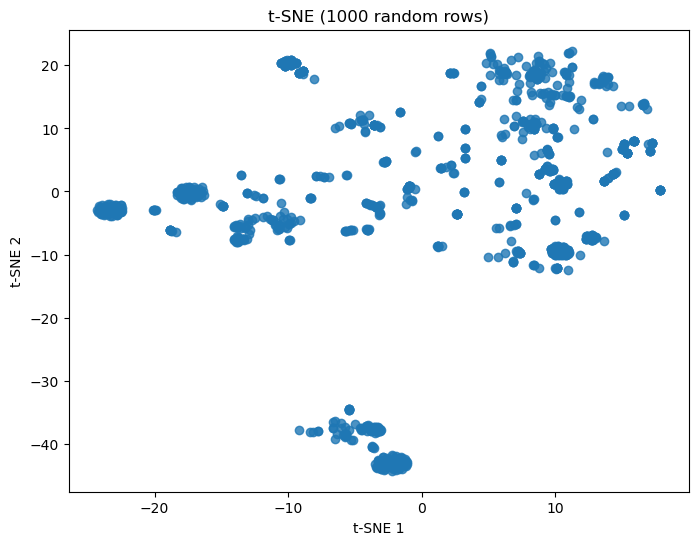

In [128]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.8)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE (1000 random rows)")
plt.show()


## Обучение моделей

### Кластеризация

In [59]:
import pandas as pd
from scipy import sparse
from sklearn.cluster import HDBSCAN
import joblib

X = df  # sparse matrix or DataFrame

clusterer = HDBSCAN(min_cluster_size=50, min_samples=10, metric="euclidean")
labels = clusterer.fit_predict(X)

if sparse.issparse(X):
    train_df = pd.DataFrame.sparse.from_spmatrix(X)
else:
    train_df = X.copy()

train_df["cluster"] = labels
joblib.dump(clusterer, "../../../logs/clusterer.joblib")


['../../../logs/clusterer.joblib']

In [61]:
train_df.loc[:1506, 'cluster'] = -1

In [49]:
train_df.to_csv("../../../logs/dataframe_with_attacks.hdf", index=False)

In [62]:
train_df['cluster'].value_counts()

cluster
 30    3034
-1     1854
 33    1016
 40     774
 34     659
 35     516
 39     470
 32     353
 0      310
 7      298
 26     271
 28     270
 23     231
 25     220
 1      206
 22     198
 36     189
 10     172
 12     143
 27     127
 15     124
 16     114
 31     113
 20     113
 9      105
 4      103
 5      102
 21      94
 13      92
 38      85
 18      84
 2       84
 14      79
 17      77
 6       76
 19      75
 37      73
 29      68
 8       66
 24      61
 3       60
 11      55
Name: count, dtype: int64

In [1]:
data = pd.read_csv("../../logs/dataframe.csv")

NameError: name 'pd' is not defined

In [2]:
data

NameError: name 'data' is not defined

In [7]:
from sklearn.manifold import TSNE # здесь подключаем метод TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD

feature_cols = data.select_dtypes(include=['number']).columns
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(data)
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_sample_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=129,      # good for ~125 points
    init='pca',
    learning_rate='auto',
    random_state=42
)

X_tsne = tsne.fit_transform(X_reduced)



NameError: name 'copy_data' is not defined

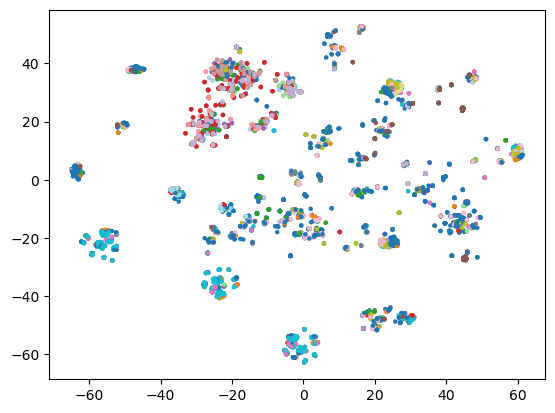

In [33]:
data['tsne_x'] = X_tsne[:, 0]
data['tsne_y'] = X_tsne[:, 1]

plt.scatter(data.tsne_x, data.tsne_y, c=data.cluster, cmap='tab20', s=5)
plt.show()


### Классификация

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df.drop('cluster', axis=1)
y = data['cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # IMPORTANT for sparse data
    ('clf', LogisticRegression(
        max_iter=3000,
        n_jobs=-1,
        solver='lbfgs'
    ))
])

pipe.fit(X_train, y_train)


AttributeError: 'csr_matrix' object has no attribute 'drop'

In [64]:
from scipy import sparse
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np

# Вариант 1: df — уже матрица признаков (csr_matrix)
X = df
y = labels  # или train_df["cluster"].to_numpy(), но НЕ data['cluster']

# Важно: у y должно быть >=2 классов
print(np.unique(y, return_counts=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(
        max_iter=3000,
        n_jobs=-1,
        solver="saga"   # для sparse обычно стабильнее
    ))
])

pipe.fit(X_train, y_train)


(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40]), array([ 347,  310,  206,   84,   60,  103,  102,   76,  298,   66,  105,
        172,   55,  143,   92,   79,  124,  114,   77,   84,   75,  113,
         94,  198,  231,   61,  220,  271,  127,  270,   68, 4541,  113,
        353, 1016,  659,  516,  189,   73,   85,  470,  774]))


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,False
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [67]:
import numpy as np
from dataclasses import dataclass
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# -----------------------------
# 1) Подготовка X/y
# -----------------------------
# Если df уже csr_matrix -> это X, а y берём отдельно
# Если df DataFrame с колонкой cluster -> разделяем прямо из него
def prepare_xy(df, y_source=None):
    if sparse.issparse(df):
        X = df
        if y_source is None:
            raise ValueError("Передай y_source (например data['cluster']) для sparse X")
        y = np.asarray(y_source)
        return X, y

    if "cluster" not in df.columns:
        raise ValueError("В DataFrame нет колонки 'cluster'")
    X = df.drop(columns=["cluster"])
    y = df["cluster"].to_numpy()
    return X, y


@dataclass
class TwoStageLogReg:
    anomaly_threshold: float = 0.40
    anomaly_label: int = -1

    def __post_init__(self):
        # Этап 1: anomaly vs normal
        self.anomaly_pipe = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(
                solver="saga",
                max_iter=5000,
                n_jobs=-1,
                class_weight="balanced",
            )),
        ])
        # Этап 2: классификация только нормальных кластеров
        self.normal_pipe = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(
                solver="saga",
                max_iter=5000,
                n_jobs=-1,
                class_weight="balanced",
                multi_class="multinomial",
            )),
        ])

    def fit(self, X, y):
        y = np.asarray(y)
        y_bin = (y == self.anomaly_label).astype(int)

        self.anomaly_pipe.fit(X, y_bin)

        normal_mask = y != self.anomaly_label
        if normal_mask.sum() == 0:
            raise ValueError("В train нет нормальных классов (все = -1)")
        self.normal_pipe.fit(X[normal_mask], y[normal_mask])
        return self

    def anomaly_proba(self, X):
        return self.anomaly_pipe.predict_proba(X)[:, 1]

    def predict(self, X, threshold=None):
        thr = self.anomaly_threshold if threshold is None else threshold
        p_anom = self.anomaly_proba(X)
        normal_pred = self.normal_pipe.predict(X)
        pred = normal_pred.copy()
        pred[p_anom >= thr] = self.anomaly_label
        return pred


# -----------------------------
# 2) Обучение
# -----------------------------
# Пример:
# X, y = prepare_xy(df, y_source=data["cluster"])
X, y = prepare_xy(df, y_source=train_df["cluster"])

try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
except ValueError:
    # Если какие-то классы слишком редкие для stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

model = TwoStageLogReg(anomaly_threshold=0.40, anomaly_label=-1)
model.fit(X_train, y_train)

# -----------------------------
# 3) Оценка
# -----------------------------
y_pred = model.predict(X_test)
print("Multiclass report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Отдельно метрики именно для аномалии
y_test_bin = (y_test == -1).astype(int)
y_pred_bin = (y_pred == -1).astype(int)
print("\nBinary anomaly report (-1 vs rest):")
print(classification_report(y_test_bin, y_pred_bin, target_names=["normal", "anomaly"], zero_division=0))

# -----------------------------
# 4) Подбор порога аномалии
# -----------------------------
best_thr, best_f1 = None, -1.0
for thr in np.arange(0.20, 0.81, 0.05):
    y_thr = model.predict(X_test, threshold=float(thr))
    f1_anom = f1_score((y_test == -1).astype(int), (y_thr == -1).astype(int), zero_division=0)
    if f1_anom > best_f1:
        best_f1, best_thr = f1_anom, float(thr)

print(f"\nBest anomaly threshold: {best_thr:.2f}, F1(anomaly)={best_f1:.4f}")


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multiclass report:
              precision    recall  f1-score   support

          -1       0.46      0.93      0.62       371
           0       0.91      0.47      0.62        62
           1       0.74      0.63      0.68        41
           2       0.26      0.59      0.36        17
           3       0.67      0.83      0.74        12
           4       0.42      0.38      0.40        21
           5       0.37      0.35      0.36        20
           6       0.78      0.93      0.85        15
           7       0.76      0.27      0.40        60
           8       0.10      0.46      0.17        13
           9       0.23      0.29      0.26        21
          10       0.42      0.32      0.37        34
          11       0.50      0.55      0.52        11
          12       0.45      0.34      0.39        29
          13       0.17      0.06      0.08        18
          14       0.07      0.25      0.11        16
          15       0.41      0.36      0.38        25
        

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [65]:
from sklearn.metrics import classification_report

y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

          -1       0.41      0.49      0.45        69
           0       0.56      0.52      0.54        62
           1       0.71      0.54      0.61        41
           2       0.60      0.35      0.44        17
           3       0.64      0.58      0.61        12
           4       0.50      0.14      0.22        21
           5       0.47      0.35      0.40        20
           6       0.59      0.67      0.62        15
           7       0.48      0.50      0.49        60
           8       0.20      0.08      0.11        13
           9       0.42      0.38      0.40        21
          10       0.36      0.50      0.42        34
          11       0.80      0.36      0.50        11
          12       0.65      0.38      0.48        29
          13       0.38      0.17      0.23        18
          14       0.80      0.25      0.38        16
          15       0.55      0.44      0.49        25
          16       0.90    

In [68]:
import joblib

joblib.dump(model, "log_classifier_2.joblib")


['log_classifier_2.joblib']

In [9]:
clusterer

NameError: name 'clusterer' is not defined

In [72]:
joblib.dump(clusterer, "clusterer_2.joblib")

['clusterer_2.joblib']

In [14]:
import pandas as pd
import scipy.sparse

# Create a 3x3 sparse matrix
sparse_matrix = scipy.sparse.eye(3)

# Convert to DataFrame
df = pd.DataFrame.sparse.from_spmatrix(sparse_matrix, columns=["red", "green", "blue"],)

df


,red,green,blue
0,1.0,0,0
1,0,1.0,0
2,0,0,1.0


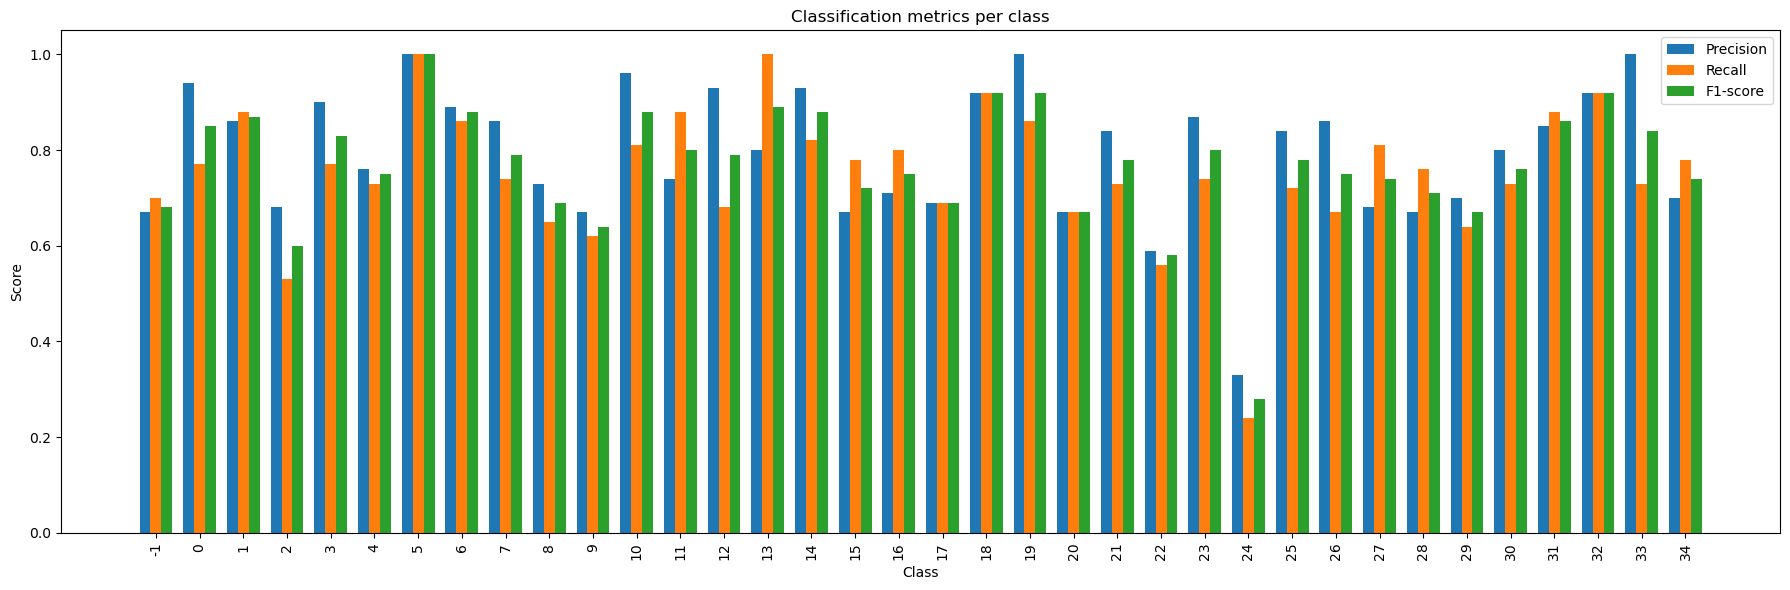

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Данные из classification report
classes = [
    -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19,
    20, 21, 22, 23, 24, 25, 26, 27, 28,
    29, 30, 31, 32, 33, 34
]

precision = [
    0.67, 0.94, 0.86, 0.68, 0.90, 0.76, 1.00, 0.89, 0.86,
    0.73, 0.67, 0.96, 0.74, 0.93, 0.80, 0.93, 0.67, 0.71,
    0.69, 0.92, 1.00, 0.67, 0.84, 0.59, 0.87, 0.33, 0.84,
    0.86, 0.68, 0.67, 0.70, 0.80, 0.85, 0.92, 1.00, 0.70
]

recall = [
    0.70, 0.77, 0.88, 0.53, 0.77, 0.73, 1.00, 0.86, 0.74,
    0.65, 0.62, 0.81, 0.88, 0.68, 1.00, 0.82, 0.78, 0.80,
    0.69, 0.92, 0.86, 0.67, 0.73, 0.56, 0.74, 0.24, 0.72,
    0.67, 0.81, 0.76, 0.64, 0.73, 0.88, 0.92, 0.73, 0.78
]

f1 = [
    0.68, 0.85, 0.87, 0.60, 0.83, 0.75, 1.00, 0.88, 0.79,
    0.69, 0.64, 0.88, 0.80, 0.79, 0.89, 0.88, 0.72, 0.75,
    0.69, 0.92, 0.92, 0.67, 0.78, 0.58, 0.80, 0.28, 0.78,
    0.75, 0.74, 0.71, 0.67, 0.76, 0.86, 0.92, 0.84, 0.74
]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(18, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, classes, rotation=90)
plt.ylim(0, 1.05)
plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Classification metrics per class')
plt.legend()
plt.tight_layout()
plt.show()


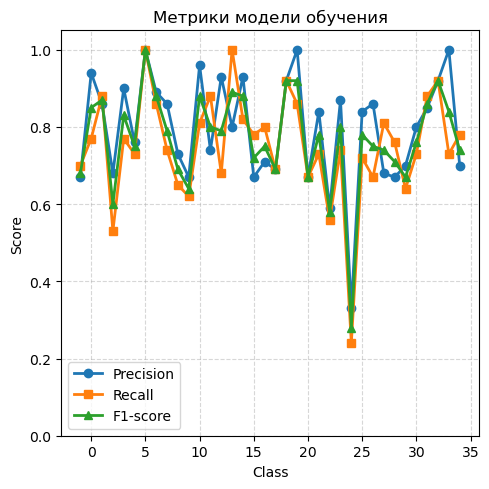

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Классы
classes = [
    -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19,
    20, 21, 22, 23, 24, 25, 26, 27, 28,
    29, 30, 31, 32, 33, 34
]

precision = [
    0.67, 0.94, 0.86, 0.68, 0.90, 0.76, 1.00, 0.89, 0.86,
    0.73, 0.67, 0.96, 0.74, 0.93, 0.80, 0.93, 0.67, 0.71,
    0.69, 0.92, 1.00, 0.67, 0.84, 0.59, 0.87, 0.33, 0.84,
    0.86, 0.68, 0.67, 0.70, 0.80, 0.85, 0.92, 1.00, 0.70
]

recall = [
    0.70, 0.77, 0.88, 0.53, 0.77, 0.73, 1.00, 0.86, 0.74,
    0.65, 0.62, 0.81, 0.88, 0.68, 1.00, 0.82, 0.78, 0.80,
    0.69, 0.92, 0.86, 0.67, 0.73, 0.56, 0.74, 0.24, 0.72,
    0.67, 0.81, 0.76, 0.64, 0.73, 0.88, 0.92, 0.73, 0.78
]

f1 = [
    0.68, 0.85, 0.87, 0.60, 0.83, 0.75, 1.00, 0.88, 0.79,
    0.69, 0.64, 0.88, 0.80, 0.79, 0.89, 0.88, 0.72, 0.75,
    0.69, 0.92, 0.92, 0.67, 0.78, 0.58, 0.80, 0.28, 0.78,
    0.75, 0.74, 0.71, 0.67, 0.76, 0.86, 0.92, 0.84, 0.74
]

plt.figure(figsize=(5, 5))

plt.plot(classes, precision, marker='o', linewidth=2, label='Precision')
plt.plot(classes, recall, marker='s', linewidth=2, label='Recall')
plt.plot(classes, f1, marker='^', linewidth=2, label='F1-score')

plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Метрики модели обучения')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


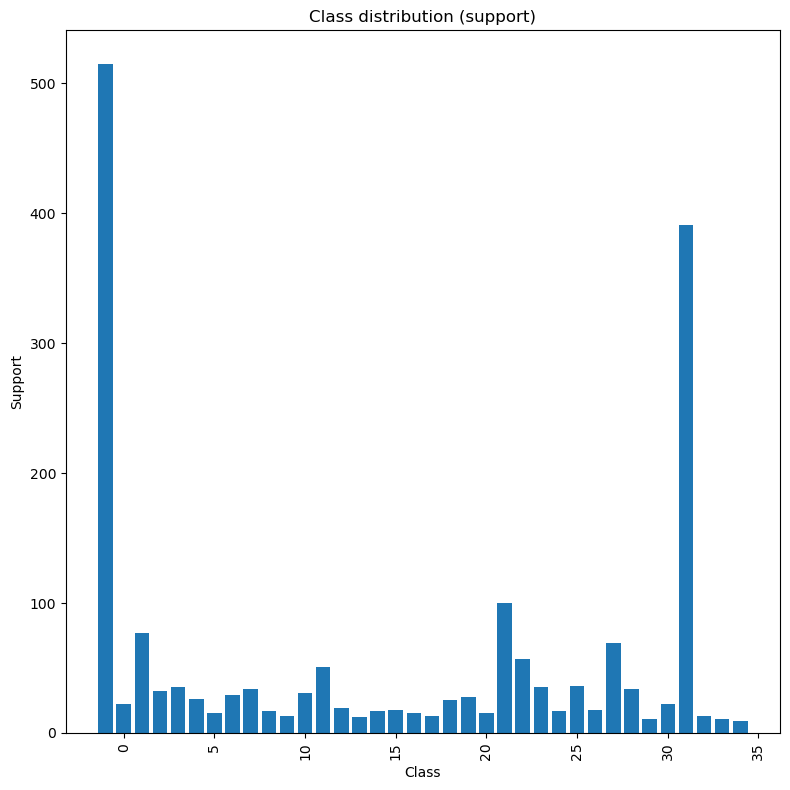

In [2]:
support = [
    515, 22, 77, 32, 35, 26, 15, 29, 34, 17, 13,
    31, 51, 19, 12, 17, 18, 15, 13, 25, 28,
    15, 100, 57, 35, 17, 36, 18, 69, 34,
    11, 22, 391, 13, 11, 9
]

plt.figure(figsize=(8, 8))
plt.bar(classes, support)
plt.xlabel('Class')
plt.ylabel('Support')
plt.title('Class distribution (support)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


<Figure size 600x600 with 0 Axes>

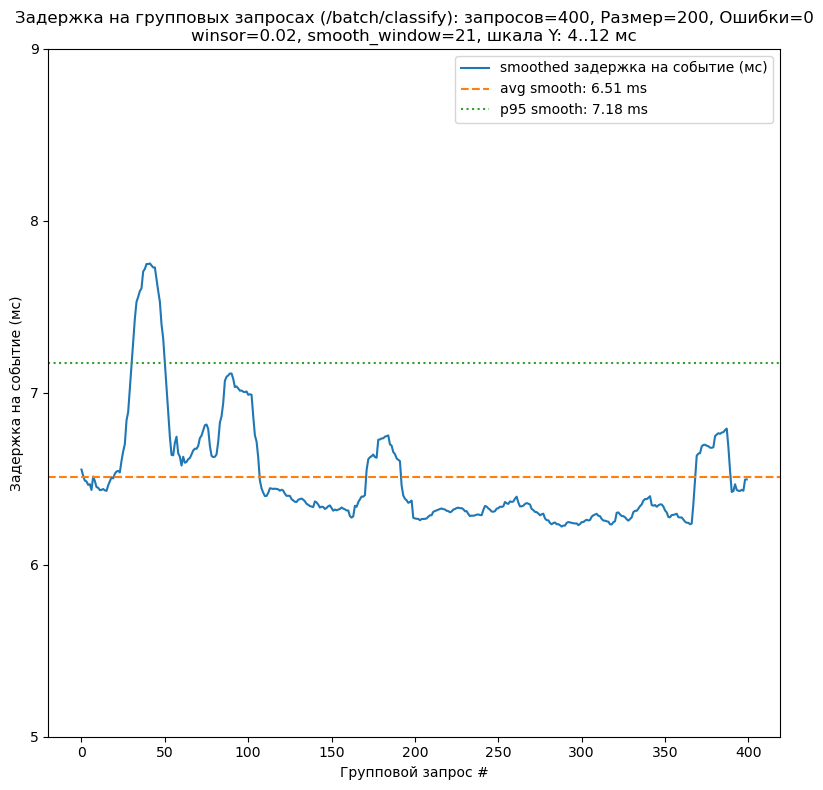

Средняя задержка на группу: 130.97 ms | Средняя задержка на событие latency: 6.55 ms | P95 задержка на событие: 7.62 ms | median/P99/max на событие: 6.34/9.87/15.05 ms | Estimated event throughput: 152.71 RPS | ошибка: 0


In [13]:
#!/usr/bin/env python3
import argparse
import json
import math
import statistics
import time
from pathlib import Path

import matplotlib.pyplot as plt
import requests


DEFAULT_PAYLOAD = {
    "source": {"ip": "31.185.5.73"},
    "type": "apache_access",
    "@timestamp": "2025-12-08T22:32:13.000Z",
    "event": {
        "original": (
            "31.185.5.73 - - [09/Dec/2025:01:32:13 +0300] "
            "\"GET /lib/javascript.php/1758485667/lib/requirejs/require.min.js HTTP/1.1\" "
            "200 9685 \"https://it548.ru/login/index.php\" "
            "\"Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 "
            "YaBrowser/25.10.0.0 Safari/537.36\""
        ),
        "type": ["access", "connection"],
        "dataset": "apache.access",
        "module": "apache",
        "category": ["web", "authentication"],
        "kind": "event",
    },
    "host": {"name": "e9828ba7e444"},
    "message": (
        "31.185.5.73 - - [09/Dec/2025:01:32:13 +0300] "
        "\"GET /lib/javascript.php/1758485667/lib/requirejs/require.min.js HTTP/1.1\" "
        "200 9685 \"https://it548.ru/login/index.php\" "
        "\"Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 "
        "YaBrowser/25.10.0.0 Safari/537.36\""
    ),
    "http": {
        "response": {"status_code": 200, "body": {"bytes": 9685}},
        "version": "1.1",
        "request": {"referrer": "https://it548.ru/login/index.php", "method": "GET"},
    },
    "url": {
        "original": "/lib/javascript.php/1758485667/lib/requirejs/require.min.js",
        "path": "/lib/javascript.php/1758485667/lib/requirejs/require.min.js",
    },
    "user_agent": {
        "original": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 "
            "YaBrowser/25.10.0.0 Safari/537.36"
        ),
        "version": "25.10.0.0",
        "os": {"version": "10", "full": "Windows 10", "name": "Windows"},
        "device": {"name": "Other"},
        "name": "Yandex Browser",
    },
    "ecs": {"version": "8.0"},
    "log": {"file": {"path": "/var/log/test_logs/moodle_access.log"}},
}


def load_payload(path: str | None) -> dict:
    if not path:
        return DEFAULT_PAYLOAD
    with open(path, "r", encoding="utf-8") as fh:
        return json.load(fh)


def p95(values: list[float]) -> float:
    if not values:
        return 0.0
    if len(values) < 20:
        return max(values)
    return statistics.quantiles(values, n=20)[18]


def quantile(values: list[float], q: float) -> float:
    if not values:
        return 0.0
    if q <= 0:
        return min(values)
    if q >= 1:
        return max(values)
    s = sorted(values)
    pos = q * (len(s) - 1)
    lo = int(math.floor(pos))
    hi = int(math.ceil(pos))
    if lo == hi:
        return s[lo]
    frac = pos - lo
    return s[lo] * (1.0 - frac) + s[hi] * frac


def winsorize(values: list[float], tail_frac: float) -> list[float]:
    if not values or tail_frac <= 0:
        return values[:]
    tail = min(max(tail_frac, 0.0), 0.49)
    lo = quantile(values, tail)
    hi = quantile(values, 1.0 - tail)
    return [min(max(v, lo), hi) for v in values]


def moving_average(values: list[float], window: int) -> list[float]:
    if not values:
        return []
    w = max(1, int(window))
    out: list[float] = []
    run_sum = 0.0
    for i, v in enumerate(values):
        run_sum += v
        if i >= w:
            run_sum -= values[i - w]
        cur_n = min(i + 1, w)
        out.append(run_sum / cur_n)
    return out


def main() -> None:
    # parser = argparse.ArgumentParser(description="Plot ML service latency for /batch/classify")
    # parser.add_argument("--url", default="http://localhost:8000", help="Base ML service URL")
    # parser.add_argument("--requests", type=int, default=300, help="Number of batch requests to send")
    # parser.add_argument("--batch-size", type=int, default=10, help="Events per batch request")
    # parser.add_argument("--warmup", type=int, default=20, help="Number of warmup requests")
    # parser.add_argument("--timeout", type=float, default=10.0, help="Request timeout, seconds")
    # parser.add_argument("--payload", default=None, help="Path to JSON payload file")
    # parser.add_argument(
    #     "--winsor-tail",
    #     type=float,
    #     default=0.02,
    #     help="Trim fraction for outlier clipping on both tails [0..0.49]",
    # )
    # parser.add_argument(
    #     "--smooth-window",
    #     type=int,
    #     default=15,
    #     help="Window size for moving-average smoothing",
    # )
    # parser.add_argument(
    #     "--plot-raw",
    #     action="store_true",
    #     help="Also draw raw log2 series (semi-transparent)",
    # )
    # parser.add_argument("--out", default="artifacts/ml_latency.png", help="Output plot path")
    # args = parser.parse_args()

    payload = load_payload(None)
    endpoint = "http://localhost:8000/batch/classify"
    request_payload = {"logs": [payload] * 20, "return_proba": True}
    Path("artifacts/ml_latency.png").parent.mkdir(parents=True, exist_ok=True)

    batch_timings_ms: list[float] = []
    errors = 0
    error_samples: list[str] = []
    with requests.Session() as session:
        # Reuse HTTP connection to reduce latency spikes from repeated TCP handshakes.
        for _ in range(20):
            try:
                session.post(endpoint, json=request_payload, timeout=10.0)
            except Exception:
                pass

        for _ in range(400):
            t0 = time.perf_counter()
            try:
                resp = session.post(endpoint, json=request_payload, timeout=10.0)
                if resp.status_code >= 400:
                    errors += 1
                    if len(error_samples) < 5:
                        error_samples.append(f"HTTP {resp.status_code}: {resp.text[:200]}")
                else:
                    body = resp.json()
                    if body.get("failed", 0) > 0:
                        errors += 1
                        if len(error_samples) < 5:
                            error_samples.append(f"Batch failed items: {body.get('failed')}")
            except Exception as exc:
                errors += 1
                if len(error_samples) < 5:
                    error_samples.append(str(exc))
            t1 = time.perf_counter()
            batch_timings_ms.append((t1 - t0) * 1000.0)

    # Normalize per event in batch to compare runs with different batch sizes.
    event_timings_ms_raw = [value / max(20, 1) for value in batch_timings_ms]
    event_timings_ms_clip = winsorize(event_timings_ms_raw, 0.02)
    event_timings_ms_smooth = moving_average(event_timings_ms_clip, 21)

    avg_batch_ms = statistics.mean(batch_timings_ms) if batch_timings_ms else 0.0
    avg_event_ms = statistics.mean(event_timings_ms_raw) if event_timings_ms_raw else 0.0
    p95_event_ms = p95(event_timings_ms_raw)
    avg_event_rps = (1000.0 / avg_event_ms) if avg_event_ms > 0 else 0.0

    p99_event_ms = quantile(event_timings_ms_raw, 0.99)
    median_event_ms = quantile(event_timings_ms_raw, 0.50)
    max_event_ms = max(event_timings_ms_raw) if event_timings_ms_raw else 0.0

    plt.figure(figsize=(6, 6))
    # if args.plot_raw:
    #     plt.plot(
    #         event_timings_log2_raw,
    #         label="raw log2(задержка на событие в мс + 1)",
    #         color="#7f7f7f",
    #         alpha=0.35,
    #     )
    event_timings_ms_raw = [value / max(20, 1) for value in batch_timings_ms]
    event_timings_ms_clip = winsorize(event_timings_ms_raw, 0.02)
    event_timings_ms_smooth = moving_average(event_timings_ms_clip, 21)

    avg_batch_ms = statistics.mean(batch_timings_ms) if batch_timings_ms else 0.0
    avg_event_ms = statistics.mean(event_timings_ms_raw) if event_timings_ms_raw else 0.0
    p95_event_ms = p95(event_timings_ms_raw)
    avg_event_rps = (1000.0 / avg_event_ms) if avg_event_ms > 0 else 0.0

    avg_smooth_ms = statistics.mean(event_timings_ms_smooth) if event_timings_ms_smooth else 0.0
    p95_smooth_ms = p95(event_timings_ms_smooth)

    p99_event_ms = quantile(event_timings_ms_raw, 0.99)
    median_event_ms = quantile(event_timings_ms_raw, 0.50)
    max_event_ms = max(event_timings_ms_raw) if event_timings_ms_raw else 0.0

    plt.figure(figsize=(8, 8))

    plt.plot(
        event_timings_ms_smooth,
        label="smoothed задержка на событие (мс)",
        color="#1f77b4",
    )
    plt.axhline(avg_smooth_ms, color="#ff7f0e", linestyle="--", label=f"avg smooth: {avg_smooth_ms:.2f} ms")
    plt.axhline(p95_smooth_ms, color="#2ca02c", linestyle=":", label=f"p95 smooth: {p95_smooth_ms:.2f} ms")
    plt.title(
        f"Задержка на групповых запросах (/batch/classify): запросов={400}, "
        f"Размер={200}, Ошибки={errors}\n"
        f"winsor={0.02}, smooth_window={21}, шкала Y: 4..12 мс"
    )
    plt.xlabel("Групповой запрос #")
    plt.ylabel("Задержка на событие (мс)")
    plt.ylim(5, 9)
    plt.yticks(list(range(5, 10)))
    plt.legend(loc="upper right")
    plt.tight_layout()
    
    plt.show()

    print(
        f"Средняя задержка на группу: {avg_batch_ms:.2f} ms | "
        f"Средняя задержка на событие latency: {avg_event_ms:.2f} ms | "
        f"P95 задержка на событие: {p95_event_ms:.2f} ms | "
        f"median/P99/max на событие: {median_event_ms:.2f}/{p99_event_ms:.2f}/{max_event_ms:.2f} ms | "
        f"Estimated event throughput: {avg_event_rps:.2f} RPS | "
        f"ошибка: {errors}"
    )
    if error_samples:
        print("Error samples:")
        for item in error_samples:
            print(f"- {item}")


main()


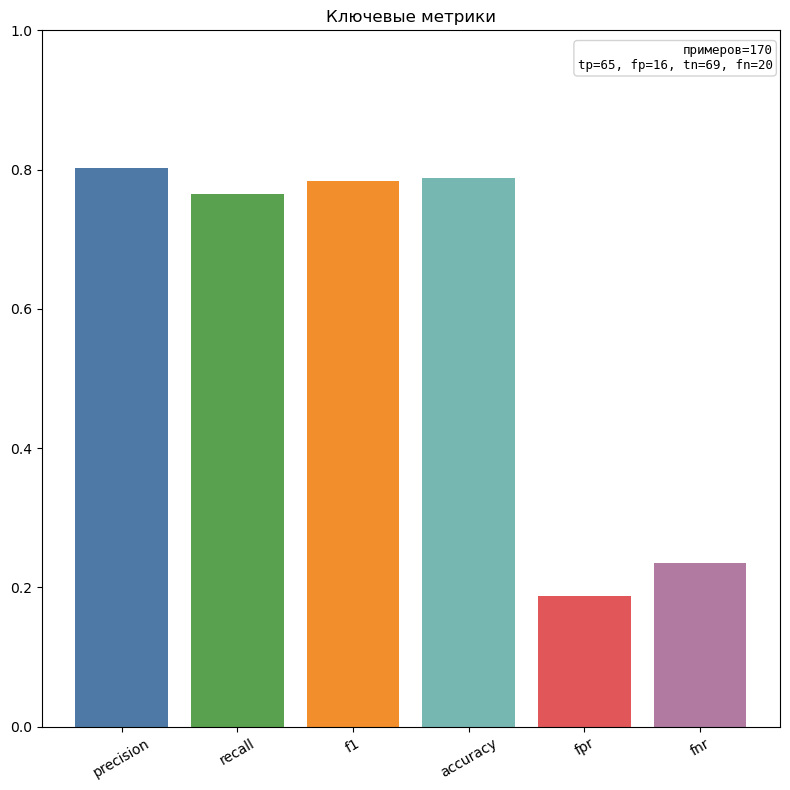

Samples: 170
Metrics: precision=0.8025, recall=0.7647, f1=0.7831, accuracy=0.7882, fpr=0.1882, fnr=0.2353
Chart rendered to current notebook/session output
Saved metrics:  /Users/infer0/PycharmProjects/eventalyzer/artifacts/ml_quality_metrics.json


In [1]:
#!/usr/bin/env python3
import argparse
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt


@dataclass
class Sample:
    report_file: str
    index: int
    group: str
    name: str
    method: str
    path: str
    y_true: int
    y_pred: int
    cluster: int | None
    proba: float | None
    anomaly_proba: float | None
    elapsed_ms: float | None
    error: str | None


def safe_div(n: float, d: float) -> float:
    return n / d if d else 0.0


def parse_one_report(path: Path, threshold: float) -> list[Sample]:
    obj = json.loads(path.read_text(encoding="utf-8"))
    if obj.get("test") != "test_random_5_attack_and_5_normal_strict_directional_asserts":
        return []

    mixed_items = obj.get("mixed_items", [])
    response = obj.get("response", {})
    results = response.get("results", []) if isinstance(response, dict) else []
    result_by_index: dict[int, dict[str, Any]] = {}
    for item in results:
        if isinstance(item, dict) and isinstance(item.get("index"), int):
            result_by_index[item["index"]] = item

    parsed: list[Sample] = []
    for idx, item in enumerate(mixed_items):
        if not isinstance(item, dict):
            continue

        result = result_by_index.get(idx, {})
        cluster = result.get("cluster")
        proba_raw = result.get("proba")
        proba = float(proba_raw) if isinstance(proba_raw, (int, float)) else None
        anomaly_proba_raw = result.get("anomaly_proba")
        anomaly_proba = float(anomaly_proba_raw) if isinstance(anomaly_proba_raw, (int, float)) else None

        # old reports may not have anomaly_proba -> fallback to cluster label
        if anomaly_proba is not None:
            y_pred = 1 if anomaly_proba >= threshold else 0
        else:
            y_pred = 1 if cluster == -1 else 0

        y_true = 1 if bool(item.get("expected_anomaly")) else 0
        elapsed_val = result.get("elapsed")
        elapsed_ms = float(elapsed_val) * 1000.0 if isinstance(elapsed_val, (int, float)) else None

        parsed.append(
            Sample(
                report_file=path.name,
                index=idx,
                group=str(item.get("group", "")),
                name=str(item.get("name", "")),
                method=str(item.get("method", "")),
                path=str(item.get("path", "")),
                y_true=y_true,
                y_pred=y_pred,
                cluster=int(cluster) if isinstance(cluster, int) else None,
                proba=proba,
                anomaly_proba=anomaly_proba,
                elapsed_ms=elapsed_ms,
                error=result.get("error") if isinstance(result, dict) else None,
            )
        )

    return parsed


def collect_samples(reports_dir: Path, limit: int, threshold: float) -> list[Sample]:
    files = sorted(reports_dir.glob("attack_vs_normal_random_*.json"))
    if limit > 0:
        files = files[-limit:]

    all_rows: list[Sample] = []
    for report_file in files:
        all_rows.extend(parse_one_report(report_file, threshold))
    return all_rows


def confusion(rows: list[Sample]) -> tuple[int, int, int, int]:
    tp = sum(1 for r in rows if r.y_true == 1 and r.y_pred == 1)
    fp = sum(1 for r in rows if r.y_true == 0 and r.y_pred == 1)
    tn = sum(1 for r in rows if r.y_true == 0 and r.y_pred == 0)
    fn = sum(1 for r in rows if r.y_true == 1 and r.y_pred == 0)
    return tp, fp, tn, fn


def compute_metrics(rows: list[Sample]) -> dict[str, float]:
    tp, fp, tn, fn = confusion(rows)
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    f1 = safe_div(2.0 * precision * recall, precision + recall)
    acc = safe_div(tp + tn, tp + tn + fp + fn)
    fpr = safe_div(fp, fp + tn)
    fnr = safe_div(fn, fn + tp)
    return {
        "tp": float(tp),
        "fp": float(fp),
        "tn": float(tn),
        "fn": float(fn),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": acc,
        "fpr": fpr,
        "fnr": fnr,
    }


def top_errors(rows: list[Sample], kind: str, top_n: int = 10) -> list[tuple[str, int]]:
    counts: dict[str, int] = {}
    for r in rows:
        if kind == "fp" and not (r.y_true == 0 and r.y_pred == 1):
            continue
        if kind == "fn" and not (r.y_true == 1 and r.y_pred == 0):
            continue
        key = f"{r.method} {r.path}"
        counts[key] = counts.get(key, 0) + 1
    return sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_n]


def render_key_metrics(
    metrics: dict[str, float],
    threshold: float,
    samples_count: int,
    samples_with_anomaly_proba: int,
) -> Any:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    metric_names = ["precision", "recall", "f1", "accuracy", "fpr", "fnr"]
    vals = [metrics[n] for n in metric_names]
    colors = ["#4e79a7", "#59a14f", "#f28e2b", "#76b7b2", "#e15759", "#b07aa1"]

    ax.bar(metric_names, vals, color=colors)
    ax.set_ylim(0, 1.0)
    ax.set_title("Ключевые метрики")
    ax.tick_params(axis="x", rotation=30)

    info_text = (
        f"примеров={samples_count}\n"
        f"tp={int(metrics['tp'])}, fp={int(metrics['fp'])}, "
        f"tn={int(metrics['tn'])}, fn={int(metrics['fn'])}"
    )
    ax.text(
        0.99,
        0.98,
        info_text,
        transform=ax.transAxes,
        va="top",
        ha="right",
        family="monospace",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "edgecolor": "#cccccc"},
    )

    plt.tight_layout()
    return fig


def show_figure(fig: Any) -> None:
    """Show figure inline in notebooks; fallback to pyplot show."""
    try:
        from IPython.display import display  # type: ignore

        display(fig)
    except Exception:
        plt.show()
    finally:
        plt.close(fig)


def main() -> None:
    reports_dir = Path("/Users/infer0/PycharmProjects/eventalyzer/logs/test_reports")
    if not reports_dir.exists():
        raise SystemExit(f"Reports directory not found: {reports_dir}")

    rows = collect_samples(reports_dir, 20, 0.5)
    if not rows:
        raise SystemExit(
            "No usable samples found. Expected files like attack_vs_normal_random_*.json in logs/test_reports."
        )

    with_anomaly_proba = sum(1 for r in rows if r.anomaly_proba is not None)
    metrics = compute_metrics(rows)
    fig = render_key_metrics(metrics, 0.5, len(rows), with_anomaly_proba)
    show_figure(fig)

    out = {
        "reports_dir": str(reports_dir),
        "samples": len(rows),
        "threshold": 0.5,
        "prediction_rule": "anomaly_proba>=threshold if available else cluster==-1",
        "samples_with_anomaly_proba": with_anomaly_proba,
        "metrics": metrics,
        "top_fp": top_errors(rows, "fp", 10),
        "top_fn": top_errors(rows, "fn", 10),
    }

    out_json = Path("/Users/infer0/PycharmProjects/eventalyzer/artifacts/ml_quality_metrics.json")
    out_json.parent.mkdir(parents=True, exist_ok=True)
    out_json.write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding="utf-8")

    print(f"Samples: {len(rows)}")
    print(
        "Metrics: "
        f"precision={metrics['precision']:.4f}, recall={metrics['recall']:.4f}, "
        f"f1={metrics['f1']:.4f}, accuracy={metrics['accuracy']:.4f}, "
        f"fpr={metrics['fpr']:.4f}, fnr={metrics['fnr']:.4f}"
    )
    print("Chart rendered to current notebook/session output")
    print(f"Saved metrics:  /Users/infer0/PycharmProjects/eventalyzer/artifacts/ml_quality_metrics.json")


main()
